# Full Method 1 Notebook (Using `main` module)

Refactored to import from the `main` directory.

In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import copy
from pathlib import Path

# Import from main
from main import (
    get_device, set_seed,
    load_participant, get_split_series,
    preprocess_eeg, preprocess_eeg_from_config,
    preprocess_emg, preprocess_emg_from_config, EMGNormalizer,
    preprocess_kinematics, preprocess_kinematics_from_config, KinNormalizer,
    extract_kt, extract_kt_raw,
    WAYEEGDataset,
    KGGTModel, build_kg_gt_from_config, CNN1dAligner,
    build_transformer_only_from_config,
    CombinedEMGLoss, build_loss_from_config,
    train_model, TrainConfig, TrainResult,
    collect_predictions, compute_metrics, EvalMetrics,
    prepare_batch_factory, save_checkpoint, load_checkpoint,
    print_gpu_info,
    compute_muscle_edge_prior,   # for edge-prior computation (follow-up step)
)

ROOT = Path(".")

In [2]:
set_seed(42)
device = get_device()
torch.backends.cudnn.benchmark = True
print(f"Device: {device}")

Device: cuda


In [3]:
CONFIG = {
    "outputs":{
        "figures_dir": "docs/figure/method1",
    },
    "data": {
        "participant": "P1",       
        "data_root": "data/way-eeg/raw",
        "cache_dir": "data/cache_main_stride500",
        # window_size=4000 @ 500 Hz = 8 s window; stride=250 = 0.5 s step
        # chunked transformer: 4000 / chunk_size=500 = 8 chunks of 500 → O(500²) not O(4000²)
        "window_size": 500,
        "stride": 500,
        "latency_shift_ms": 50.0,
        "fs_eeg": 500,                   # Hz
        "fs_emg": 4000,                  # Hz (raw); downsampled to fs_eeg after preprocess
        "fs_kin": 500,                   # Hz
        "n_eeg_channels": 32,
        "n_emg_channels": 5,
        "n_kin_raw": 36,                 # raw kin cols in hs.kin.sig
        "n_kin_features": 36             # k_t dimension after extraction
    },
    "preprocessing": {
        "eeg": {
            "use_6_channel_eeg": False,     # Option for 6-channel EEG selection
            "bp_low": 0.5,                  # Hz, bandpass lower bound
            "bp_high": 40.0,                # Hz, bandpass upper bound
            "artifact_method": "ica_auto",  # "asr" | "ica_auto" | "ica_manual"
            "filter_order": 4,
            "notch_freq": 50.0,             # Hz, power-line
            "asr_window_ms": 500,           # ms, ASR sliding window
            "asr_std_thresh": 5.0,          # sigma, ASR rejection threshold
            "delta_low": 0.5,               # Hz, delta-band lower bound
            "delta_high": 40.0,             # Hz, delta-band upper bound
            "use_car": False,
            "use_tkeo": True,
            #"target_channels": ["FC1", "FC2", "C3", "Cz", "C4", "CP1", "CP2", "CP6"]
        },
        "emg": {
            "bp_low": 30.0,              # Hz
            "bp_high": 300.0,            # Hz
            "filter_order": 4,
            "lp_cutoff": 8.0,           # Hz, low-pass for envelope
            "downsample_factor": 8       # 4000 -> 500 Hz
        },
        "kinematics": {
            "include_velocity": True,      # if true, output includes velocity
            "include_acceleration": True,  # if true, output includes acceleration
            "drop_indices": [12, 25, 38],  # prune rho_GL from pos, vel, acc
            "velocity_method": "sg",     # 'sg' (Savitzky-Golay) | 'bw' (Butterworth diff)
            "sg_window": 11,             # SG window length (samples, must be odd)
            "sg_poly": 3,                # SG polynomial order
            "bw_cutoff": 20.0,           # LP cutoff Hz before diff (used when method='bw')
            "bw_order": 4,               # Butterworth order (used when method='bw')
            "normalize": True            # per-feature z-score over training set
        },
    },
    "model": {
        "type": "transformer_regressor",
        "transformer": {
            "n_layers": 4,
            "n_heads": 8,
            "d_model": 128,
            "d_k": 32,
            "d_v": 32,
            "ffn_dim": 512,
            "dropout": 0.2,
            # chunk_size=500 with window_size=4000 → 8 chunks of 500
            # → O(500²)=250K scores per head (not O(4000²)=16M)
            # MUST divide window_size evenly or a RuntimeWarning fires and
            # full O(T²) attention is used (catastrophically slow).
            "chunk_size": 500
        },
        "gat": {
            "n_layers": 2,
            "node_dim": 64,
            "hidden_dim": 64,
            "heads": 4,
            "dropout": 0.2,
            "use_kinematic_guidance": False,
        },
        "decoder": {
            "out_channels": 5            # predicted EMG channels
        }
    },
    "training": {
        "loss": {
            "peak_alpha":      5.0,    # 3× emphasis on EMG burst peaks vs. baseline silence
            "lambda_reg":      0.001,   # KL anchor strength: GAT edge_bias stays near prior
            "lambda_l1": 0.05,
            "lambda_grad":     0.2,
            "rest_threshold":  0.15,
            "asymmetry": 2.5,
            "use_peak_weight": True,   # set False for ablation back to standard MSE
        },
        # ── optimizer ─────────────────────────────────────────────────────
        "optimizer":   "adamw",   # 'adam' | 'adamw'
        "weight_decay": 1e-2,     # AdamW weight decay (ignored for adam)
        # ── scheduler ─────────────────────────────────────────────────────
        "scheduler":   "cosine",  # 'reduce' | 'cosine'
        # reduce-specific
        "lr_patience": 5,
        "lr_factor":   0.5,
        # cosine-specific
        "cosine_t_max":   None,   # None → use max_epochs
        "cosine_eta_min": 1e-6,
        # ── common ────────────────────────────────────────────────────────
        "loss_lambda":  1.0,      # 1.0 = plain MSE; <1.0 enables Soft-DTW (O(T²), DO NOT use at T=4000)
        "lr": 1e-4,
        "warmup_epochs": 20,
        "transformer_lr_scale": 0.1,
        # batch_size=4 with T=4000 keeps VRAM safe on GTX 1660 Ti (6 GB).
        # effective batch = batch_size * gradient_accumulation_steps = 4 * 8 = 32
        # Tune batch_size up (e.g. 8) if VRAM is available; reduce grad_accum_steps proportionally.
        "batch_size":          32,
        "gradient_accumulation_steps": 2,
        "early_stop_patience": 50,
        "grad_clip_norm":      1.0,
        "max_epochs":          200,
        # use_amp=True: enables FP16 mixed precision via torch.autocast + GradScaler.
        # GTX 1660 Ti (sm_75 Turing) has FP16 tensor cores → ~1.5-2x speedup.
        # Requires PyTorch >= 2.0. Set False only if you see NaN losses.
        "use_amp":             True,
        "log_memory_every":    50,
        "losocv": True,           # leave-one-subject-out cross-validation
        "checkpoint_every":     1,
        "seed":                42,
    },
    "dataset": {
        # Keep in sync with data.window_size / data.stride above
        "window_size": 500,
        "stride": 500,
        "latency_shift_ms": 0.0,
    }
}
notebook_cfg = copy.deepcopy(CONFIG)

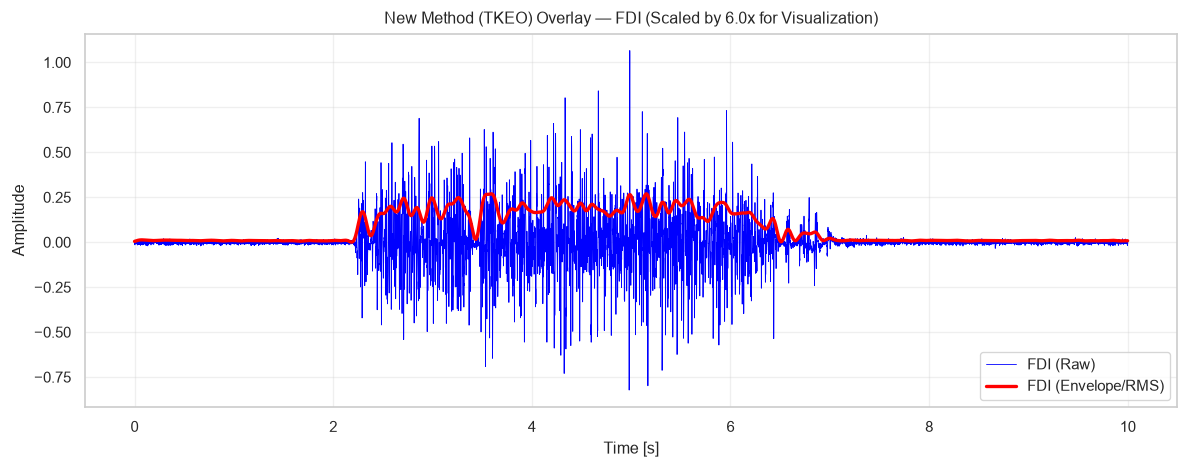

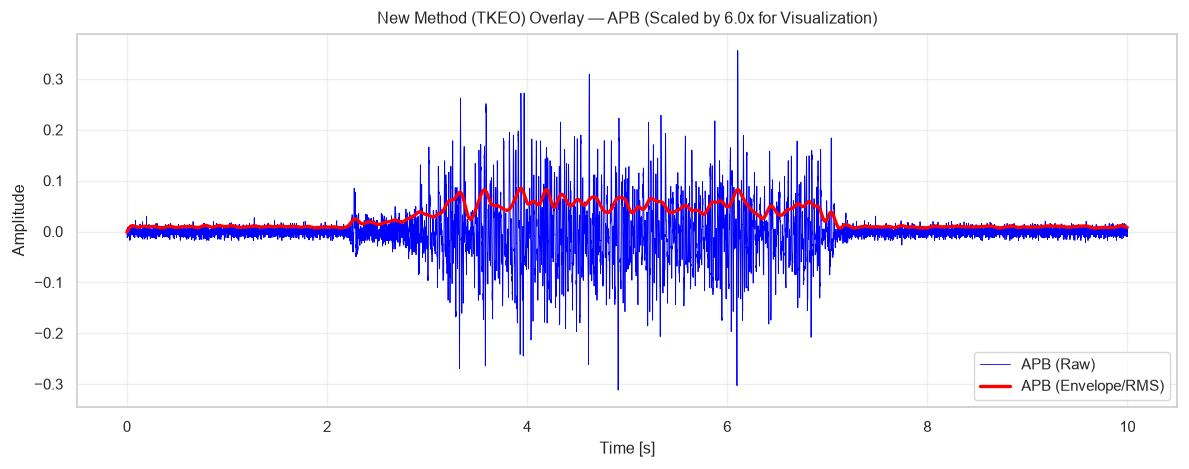

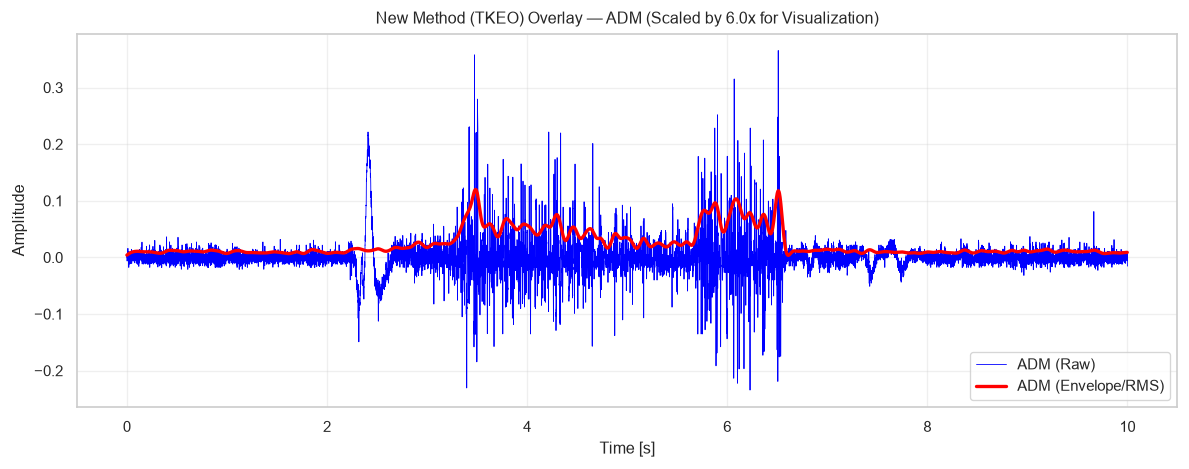

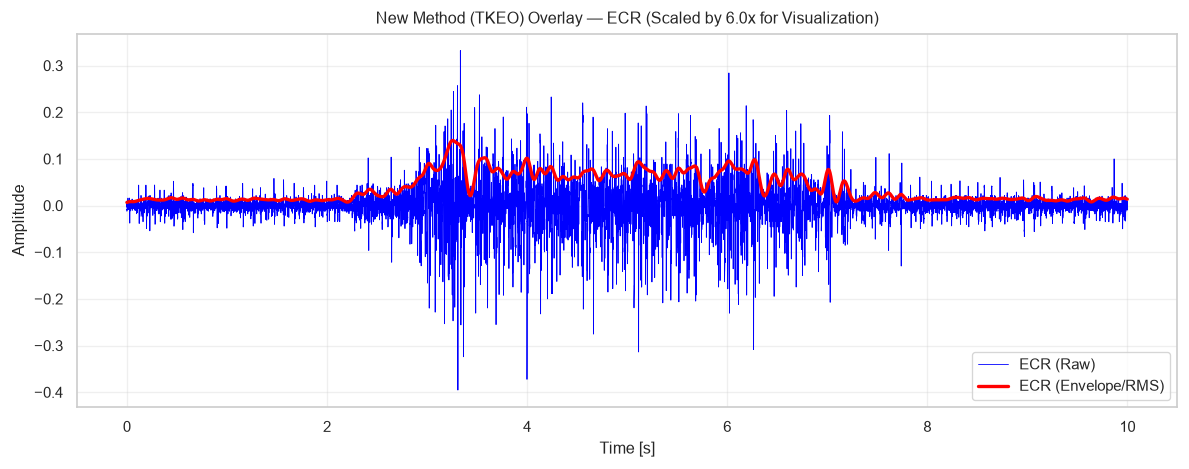

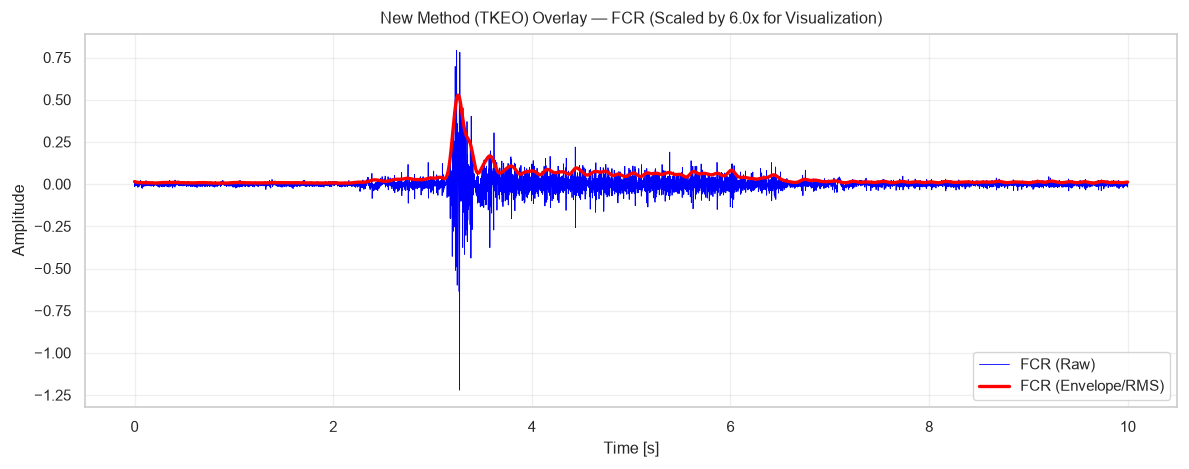

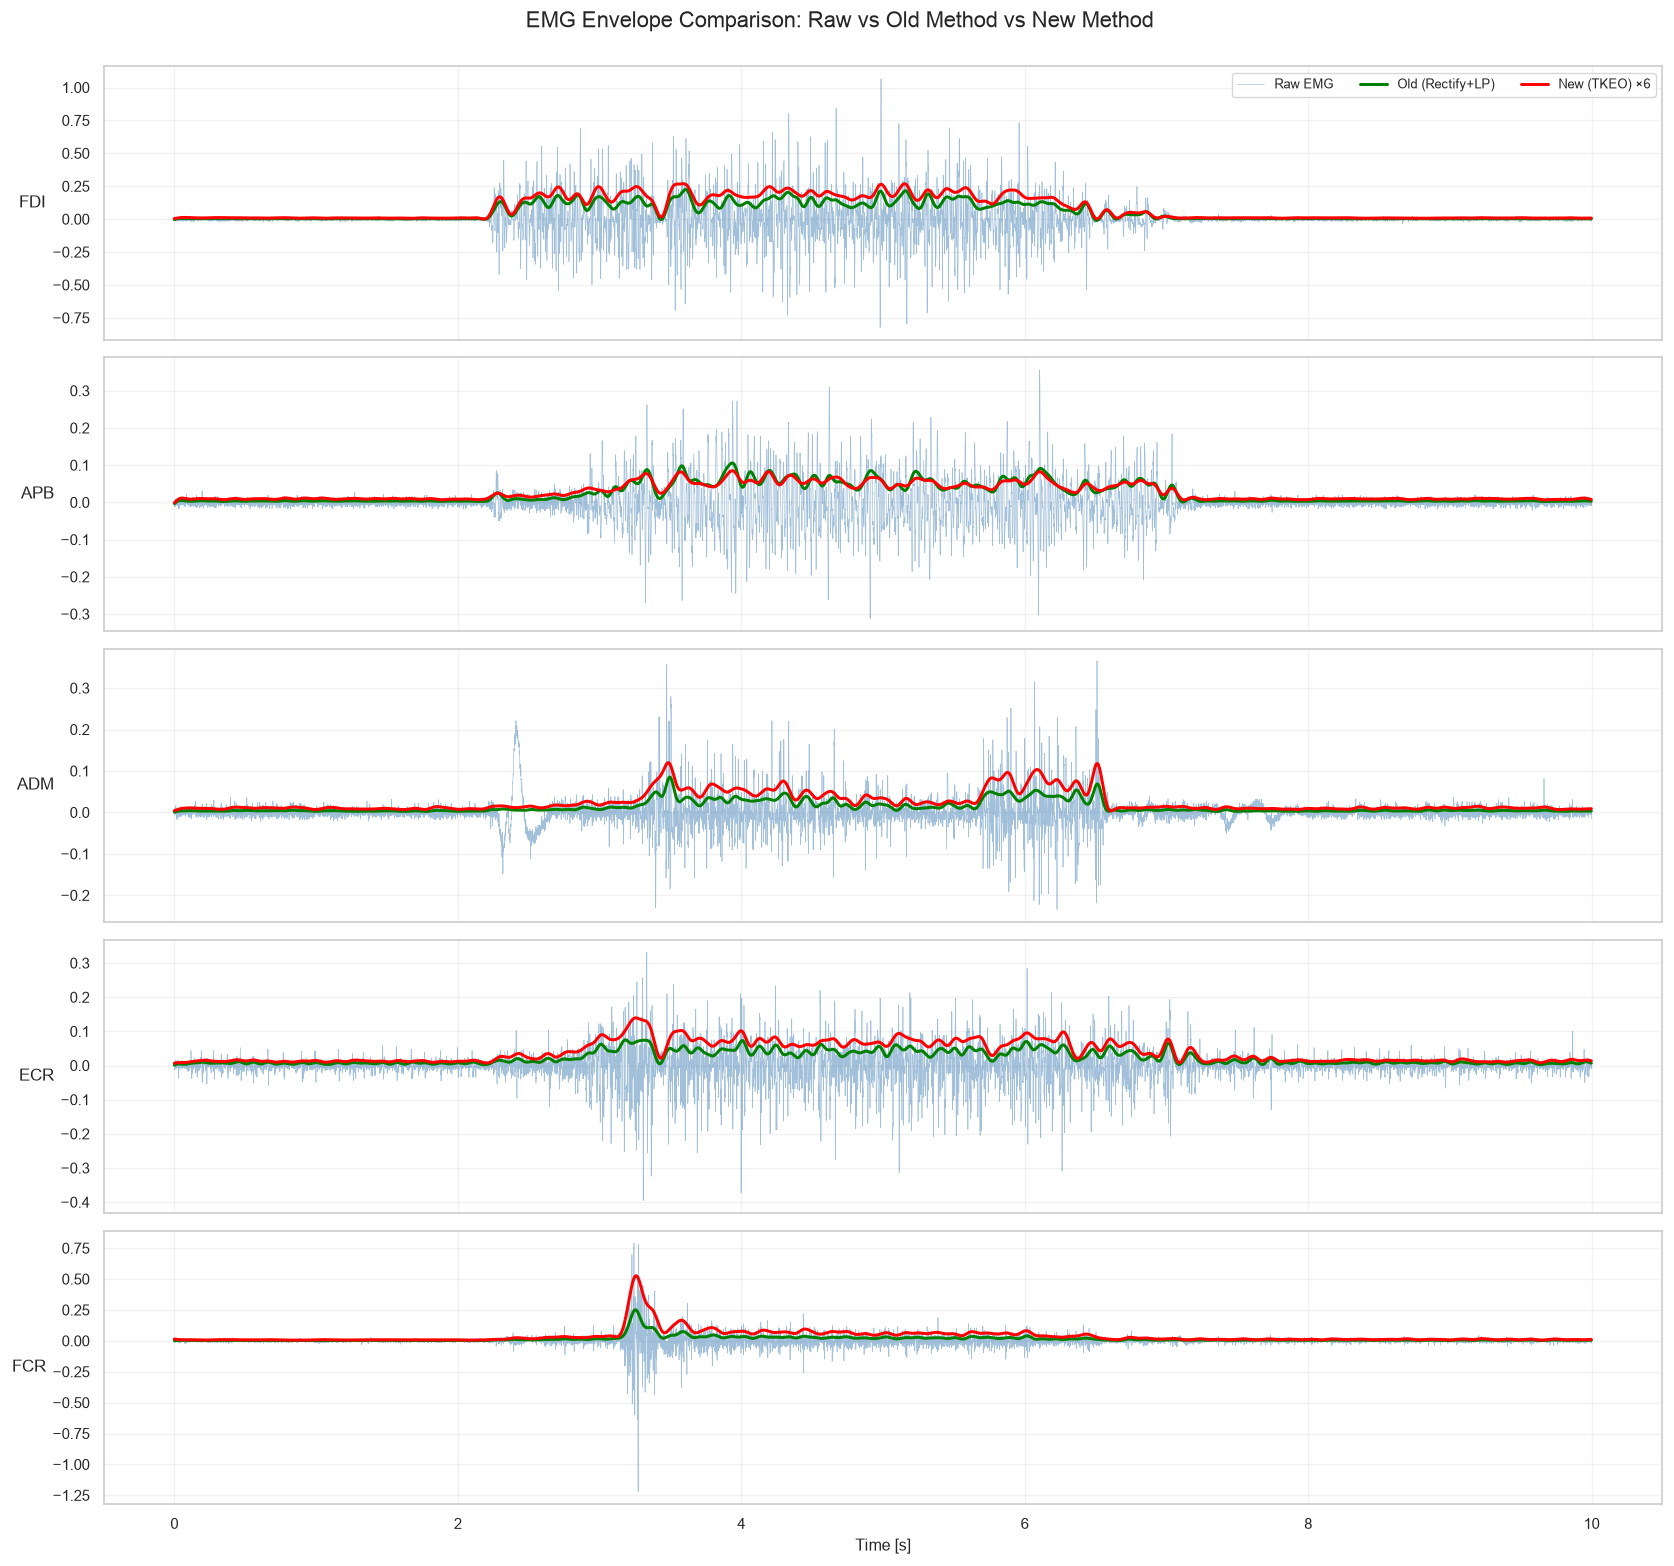

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from main.dataloader import load_hs
from main.preprocessing_emg_kin import preprocess_emg_from_config
from main.plots import plot_emg_envelope_overlay, plot_emg_method_comparison_grid

# 1. Load the continuous series dictionary
data_path = "data/way-eeg/raw/P1/HS_P1_S3.mat"  # Adjust as needed
hs_data = load_hs(data_path)
emg_raw = hs_data["emg"]
fs_raw = float(hs_data["fs_emg"])
fs_env = 500.0  # Standard downsampled rate

MUSCLE_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]  # adjust order to match your emg columns

# 2. Process with the Old Method (Rectify + Lowpass)
cfg_old = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 10.0, "use_tkeo": False}
emg_old = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_old)

# 3. Process with the New Method (TKEO + Lowpass)
cfg_new = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 8.0, "use_tkeo": True}
emg_tkeo = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_new)

# ==========================================
# 4. Slice a window
# ==========================================
start_sec = 0
end_sec = 10

start_idx_raw, end_idx_raw = int(start_sec * fs_raw), int(end_sec * fs_raw)
start_idx_env, end_idx_env = int(start_sec * fs_env), int(end_sec * fs_env)

emg_raw_slice  = emg_raw[start_idx_raw:end_idx_raw]
emg_old_slice  = emg_old[start_idx_env:end_idx_env]
emg_tkeo_slice = emg_tkeo[start_idx_env:end_idx_env]

empirical_scale_factor = 6.0  # cosmetic only, for visual amplitude matching

# ==========================================
# 5A. Per-muscle TKEO overlay (raw + TKEO envelope), all 5 muscles
# ==========================================
emg_tkeo_scaled_for_overlay = emg_tkeo_slice * empirical_scale_factor

for ch in range(emg_raw_slice.shape[1]):
    name = MUSCLE_NAMES[ch] if ch < len(MUSCLE_NAMES) else f"Ch {ch + 1}"
    fig = plot_emg_envelope_overlay(
        raw_emg=emg_raw_slice,
        env_emg=emg_tkeo_scaled_for_overlay,
        fs_raw=fs_raw,
        fs_env=fs_env,
        channel_idx=ch,
        channel_name=name,
        title=f"New Method (TKEO) Overlay — {name} "
              f"(Scaled by {empirical_scale_factor}x for Visualization)",
    )
    plt.show()

# ==========================================
# 5B. Combined comparison grid: Raw + Old + New, all 5 muscles in one figure
# ==========================================
fig_combined = plot_emg_method_comparison_grid(
    raw_emg=emg_raw_slice,
    env_old=emg_old_slice,
    env_new=emg_tkeo_slice,
    fs_raw=fs_raw,
    fs_env=fs_env,
    muscle_names=MUSCLE_NAMES,
    new_method_label="TKEO",
    old_method_label="Rectify+LP",
    new_scale_factor=empirical_scale_factor,
    start_sec=start_sec,
)
plt.show()

In [5]:
def make_preprocess_fn(cfg):
    eeg_cfg = cfg["preprocessing"]["eeg"]
    emg_cfg = cfg["preprocessing"]["emg"]
    kin_cfg = cfg["preprocessing"]["kinematics"]
    def preprocess_fn(series):
        series = dict(series)
        eeg_cfg = cfg["preprocessing"]["eeg"]
        if eeg_cfg.get("use_6_channel_eeg", False):
            target_channels = ["C3", "C4", "Cz", "CP3", "CP4", "Fz"]
            if series.get("eeg_names") is not None:
                names = list(series["eeg_names"])
                indices = [names.index(ch) for ch in target_channels if ch in names]
                if len(indices) == 6:
                    series["eeg"] = series["eeg"][:, indices]
                    series["eeg_names"] = np.array(target_channels)
        
        series["eeg"] = preprocess_eeg_from_config(
            series["eeg"],
            float(series["fs_eeg"]),
            eeg_cfg,
            channel_names=series.get("eeg_names"),
        )
        series["emg"] = preprocess_emg_from_config(
            series["emg"],
            float(series["fs_emg"]),
            emg_cfg,
        )
        series["kin"] = preprocess_kinematics_from_config(                                           
              series["kin"],                                                                           
              float(series["fs_kin"]),                                                                 
              kin_cfg,                                                                                 
        ) 
        return series

    return preprocess_fn


def resolve_participants(participant_spec):
    """Resolve participant spec to a list of int IDs.
    
    Accepts:
      "all"        -> [1, 2, ..., 12]
      "P3"         -> [3]
      3            -> [3]
      [1, 2, 3]   -> [1, 2, 3]
      ["P1", "P3"] -> [1, 3]
    """
    ALL_PARTICIPANTS = list(range(1, 13))
    if participant_spec == "all":
        return ALL_PARTICIPANTS
    if isinstance(participant_spec, (list, tuple)):
        return [int(str(p).replace("P", "")) for p in participant_spec]
    # single string like "P2" or int like 2
    return [int(str(participant_spec).replace("P", ""))]


def build_dataset_split(cfg, participants=None, split="train", root_dir=ROOT):
    """Build WAYEEGDataset for the given split.
    
    participants: list of int IDs, or None (uses cfg["data"]["participant"]).
    split: "train" | "val" | "test" | "all" | "stability"
    """
    data_cfg = cfg["data"]
    if participants is None:
        participants = resolve_participants(data_cfg["participant"])
    return WAYEEGDataset(
        data_dir=root_dir / data_cfg["data_root"],
        participants=participants,
        split=split,
        window_size=cfg["dataset"]["window_size"],
        stride=cfg["dataset"]["stride"],
        latency_shift_ms=cfg["dataset"].get("latency_shift_ms", 0.0),
        preprocess_fn=make_preprocess_fn(cfg),
        cache_dir=root_dir / data_cfg["cache_dir"]
    )

In [6]:
# ============================================================================
# Participant / LOSOCV Setup
# ============================================================================
# Supported values for notebook_cfg["data"]["participant"]:
#   "all"      → LOSOCV over all 12 subjects
#   [1,3,5]    → LOSOCV over a specific list
#   "P2" or 2  → Single-subject training (uses train/val/test series split)
#
# LOSOCV val strategy (Option 2 — scientifically clean):
#   For each fold where p_test is the held-out subject:
#     - val_participant  = last subject in the train list (rotates each fold)
#     - train on remaining N-2 subjects (all their series)
#     - val   on val_participant         (all their series) → early stopping
#     - test  on p_test                  (all their series) → final metric
#   The test subject's data NEVER influences any training decision.
# ─────────────────────────────────────────────────────────────────────────────

participant_spec = notebook_cfg["data"]["participant"]
participant_list = resolve_participants(participant_spec)
is_losocv = isinstance(participant_spec, (list, tuple)) or participant_spec == "all"

if is_losocv:
    print(f"LOSOCV mode: {len(participant_list)} participants -> {participant_list}")
    # Initialise first fold
    p_test = participant_list[0]
    # Use the LAST training subject as val (it rotates each fold naturally)
    _train_candidates = [p for p in participant_list if p != p_test]
    val_participant    = _train_candidates[-1]          # held-out from training for early stopping
    train_participants = _train_candidates[:-1]          # N-2 subjects for actual training
    test_participants  = [p_test]
    split_train = split_val = split_test = "all"
    subject_str = f"LOSO_P{p_test}"
else:
    p_id = participant_list[0]
    train_participants = [p_id]
    val_participant    = p_id          # same subject, different series
    test_participants  = [p_id]
    split_train, split_val, split_test = "train", "val", "test"
    subject_str = f"P{p_id}"

print(f"Active subject string : {subject_str}")
print(f"Train participants    : {train_participants}  ({len(train_participants)} subjects)")
print(f"Val  participant      : [{val_participant}]  (early-stopping signal — clean from test)")
print(f"Test participants     : {test_participants}   (final metric — never seen during training)")
print(f"Dataset splits        : train={split_train!r}  val={split_val!r}  test={split_test!r}")

Active subject string : P1
Train participants    : [1]  (1 subjects)
Val  participant      : [1]  (early-stopping signal — clean from test)
Test participants     : [1]   (final metric — never seen during training)
Dataset splits        : train='train'  val='val'  test='test'


In [7]:
# ============================================================================
# [OPTIONAL] Automatic LOSOCV — Run ALL Folds Unattended
# ============================================================================
# Run this cell to automatically iterate over all LOSOCV folds.
# Only runs when is_losocv = True (participant = "all" or a list).
#
# Val strategy (Option 2 — scientifically clean):
#   val_participant = last element of each fold's train list
#   → early stopping never touches the test subject's data
#
# Checkpoints saved to: outputs/checkpoints_main_stage1|2/LOSO_P{N}/
# Figures saved to:     outputs/figures/
# Summary CSV saved to: outputs/losocv_results.csv
#
# Note: Variables from the LAST fold are saved to global scope
# so that downstream individual plotting/evaluation cells can run seamlessly!
# ─────────────────────────────────────────────────────────────────────────────
import copy, gc, time, os
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from torch.utils.data import DataLoader
from main import (
    build_transformer_only_from_config, build_kg_gt_from_config,
    train_model, TrainConfig,
    collect_predictions, compute_metrics, load_checkpoint,
    compute_muscle_edge_prior, build_loss_from_config,
)
from main.preprocessing_emg_kin import compute_nnmf_edge_prior
from main.model import PureEEGKGTModel
from scipy.signal import coherence
from main.plots import plot_pure_eeg_triptych

if not is_losocv:
    print("Single-subject mode — skipping auto LOSOCV loop.  Run cells below instead.")
else:
    EMG_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]
    cv_rows = []
    os.makedirs("outputs/figures", exist_ok=True)

    for _fold_idx, _p_test in enumerate(participant_list):
        _t_fold = time.time()

        # ── Option 2: one training subject held-out for val ───────────────────
        _train_candidates = [p for p in participant_list if p != _p_test]
        _val_p     = _train_candidates[-1]       # rotates naturally each fold
        _train_ps  = _train_candidates[:-1]      # N-2 subjects
        _test_ps   = [_p_test]
        _subj      = f"LOSO_P{_p_test}"

        print(f"\n{'='*65}")
        print(f"  FOLD {_fold_idx+1}/{len(participant_list)}")
        print(f"  Train  : {_train_ps}  ({len(_train_ps)} subjects)")
        print(f"  Val    : [{_val_p}]  (early-stopping only)")
        print(f"  Test   : [{_p_test}]  (final metric — never seen during training)")
        print(f"{'='*65}")

        # ── Datasets ──────────────────────────────────────────────────────────
        _train_ds = build_dataset_split(notebook_cfg, participants=_train_ps, split="all")
        _val_ds   = build_dataset_split(notebook_cfg, participants=[_val_p],  split="all")
        _test_ds  = build_dataset_split(notebook_cfg, participants=_test_ps,  split="all")

        # ── Normalization stats from training fold only ────────────────────────
        def _unique_arrays(ds):
            seen, kins, emgs = set(), [], []
            for ea, ka, ma, _ in ds._windows:
                k = id(ea)
                if k not in seen:
                    seen.add(k); kins.append(ka); emgs.append(ma)
            return kins, emgs

        _tr_kins, _tr_emgs = _unique_arrays(_train_ds)
        _kin_all = np.concatenate(_tr_kins, axis=0)
        _emg_all = np.concatenate(_tr_emgs, axis=0)

        _emg_mean = torch.tensor(_emg_all.mean(0), dtype=torch.float32, device=device)
        _emg_std  = torch.clamp(torch.tensor(_emg_all.std(0),  dtype=torch.float32, device=device), min=1e-6)
        _kin_mean = torch.tensor(_kin_all.mean(0), dtype=torch.float32, device=device)
        _kin_std  = torch.clamp(torch.tensor(_kin_all.std(0),  dtype=torch.float32, device=device), min=1e-6)

        # ── Edge prior + loss ─────────────────────────────────────────────────
        _prior_np   = compute_nnmf_edge_prior(_tr_emgs, vaf_threshold=0.90)
        _edge_prior = torch.from_numpy(_prior_np)
        _loss_fn    = build_loss_from_config(notebook_cfg["training"])

        # ── prepare_batch ─────────────────────────────────────────────────────
        def _make_pb(em, es, dev):
            def _pb(eeg, kin, emg):
                eeg = eeg.to(dev, non_blocking=True)
                emg = emg.to(dev, non_blocking=True)
                return {"eeg": eeg}, (emg - em) / es
            return _pb
        _pb = _make_pb(_emg_mean, _emg_std, device)

        # ── Dims ──────────────────────────────────────────────────────────────
        _s_eeg, _s_kin, _s_emg = _train_ds[0]
        _bi, _ = _pb(_s_eeg.unsqueeze(0), _s_kin.unsqueeze(0), _s_emg.unsqueeze(0))
        _eeg_dim = _s_eeg.shape[-1]

        # ── DataLoaders ───────────────────────────────────────────────────────
        _bs = notebook_cfg["training"]["batch_size"]
        _tr_loader  = DataLoader(_train_ds, batch_size=_bs, shuffle=True,  drop_last=True,  pin_memory=True, num_workers=0)
        _val_loader = DataLoader(_val_ds,   batch_size=_bs, shuffle=False, pin_memory=True, num_workers=0)
        _te_loader  = DataLoader(_test_ds,  batch_size=_bs, shuffle=False, pin_memory=True, num_workers=0)

        # ── SINGLE STAGE: Pure EEG KG-GT ───────────────────────────────────
        print(f"  Single Stage: Pure EEG KG-GT training ({notebook_cfg['training']['max_epochs']} epochs) ...")
        model = PureEEGKGTModel(
            transformer_cfg=notebook_cfg["model"]["transformer"],
            input_dim=_eeg_dim,
            node_dim=notebook_cfg["model"]["gat"].get("node_dim", 64),
            gat_hidden_dim=notebook_cfg["model"]["gat"].get("hidden_dim", 64),
            gat_heads=notebook_cfg["model"]["gat"].get("heads", 4),
            out_channels=notebook_cfg["model"]["decoder"].get("out_channels", 5),
            n_gat_layers=notebook_cfg["model"]["gat"].get("n_layers", 2),
            gat_dropout=notebook_cfg["model"]["gat"].get("dropout", 0.1),
            edge_prior=_edge_prior,
            causal_cross_attention=False
        ).to(device)

        train_cfg = TrainConfig.from_config(
            notebook_cfg["training"],
            max_epochs=notebook_cfg["training"]["max_epochs"],
            lr=notebook_cfg["training"]["lr"],
        )
        train_cfg.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_method2") + f"/{_subj}"
        result = train_model(
            model=model, train_loader=_tr_loader, val_loader=_val_loader,
            prepare_batch=_pb, loss_fn=_loss_fn, device=device, cfg=train_cfg, resume=True,
        )

        # ── Evaluation on held-out TEST subject ───────────────────────────────
        _ckpt = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage2/{_subj}/best.pt"
        _bm   = copy.deepcopy(model)
        load_checkpoint(_ckpt, _bm, device)
        _bm.eval()

        _P, _Y = collect_predictions(
            _bm, _te_loader, _pb, device,
            n_channels=len(EMG_NAMES), use_amp=notebook_cfg["training"]["use_amp"],
        )
        _m = compute_metrics(_P, _Y, channel_names=EMG_NAMES)
        print(f"\n  [P{_p_test} TEST RESULTS]")
        print(_m.as_table())


        # 2. Interpretability Triptych (Continuous Test Window)
        fs = notebook_cfg["data"].get("fs_eeg", 500.0)
        eeg_full, kin_full, emg_full, block_start_idx = _test_ds._windows[0]
        start_idx = block_start_idx + int(0.0 * fs)
        end_idx   = block_start_idx + int(10.0 * fs)

        raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
        raw_emg = torch.tensor(emg_full[start_idx : end_idx])

        model_inputs, emg_norm = _pb(raw_eeg.unsqueeze(0), None, raw_emg.unsqueeze(0))
        eeg_b = model_inputs["eeg"]
        emg_b = emg_norm

        _bm.eval()
        for layer in _bm.encoder.layers:
            layer.mhsa.attention_temperature = 4.0

        with torch.no_grad():
            pred_b = _bm(eeg_b)

        pred_np = pred_b[0].cpu().float().numpy()   
        true_np = emg_b[0].cpu().float().numpy()    

        emg_mean_np = _emg_mean.cpu().numpy()
        emg_std_np  = _emg_std.cpu().numpy()
        pred_np = pred_np * emg_std_np + emg_mean_np
        true_np = true_np * emg_std_np + emg_mean_np

        eeg_attn_np = _bm.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
        
        if hasattr(_bm, "cross_attention"):
            cross_attn_np = _bm.cross_attention.last_attn_weights[0].cpu().float().numpy()
        else:
            cross_attn_np = np.zeros((4, len(EMG_NAMES), pred_np.shape[0]))

        fig_triptych = plot_pure_eeg_triptych(
            pred=pred_np,
            target=true_np,
            eeg_attn=eeg_attn_np,
            cross_attn=cross_attn_np,
            muscle_names=EMG_NAMES,
            fs=fs,
            smooth_hz=5.0,
            cfg=notebook_cfg,
        )
        plt.savefig(f"outputs/figures/interpretability_{_subj}.png", dpi=300)
        plt.close(fig_triptych)

        cv_rows.append({
            "Fold":         _subj,
            "val_subject":  f"P{_val_p}",
            "train_n":      len(_train_ps),
            **{f"RMSE_{n}":    float(_m.rmse[i])    for i, n in enumerate(EMG_NAMES)},
            **{f"nRMSE_{n}":   float(_m.nrmse[i])   for i, n in enumerate(EMG_NAMES)},
            **{f"MAE_{n}":     float(_m.mae[i])     for i, n in enumerate(EMG_NAMES)},
            **{f"Pearson_{n}": float(_m.pearson[i])  for i, n in enumerate(EMG_NAMES)},
            **{f"R2_{n}":      float(_m.r2[i])       for i, n in enumerate(EMG_NAMES)},
            **{f"VAF_{n}":     float(_m.vaf[i])      for i, n in enumerate(EMG_NAMES)},
            "RMSE_mean":    float(_m.rmse.mean()),
            "nRMSE_mean":   float(_m.nrmse.mean()),
            "MAE_mean":     float(_m.mae.mean()),
            "Pearson_mean": float(_m.pearson.mean()),
            "R2_mean":      float(_m.r2.mean()),
            "VAF_mean":     float(_m.vaf.mean()),
        })

        # ── Save Plots for this fold ──────────────────────────────────────────
        # 1. Training History
        fig_hist, ax = plt.subplots(1, 1, figsize=(8, 4), facecolor="white")
        s2_epochs = np.arange(1, len(result.history["train"]) + 1)
        ax.plot(s2_epochs, result.history["train"], label="Train", color="#2ECC71", linewidth=1.5)
        ax.plot(s2_epochs, result.history["val"],   label="Val",   color="#E74C3C", linewidth=1.5)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(f"Training History — {_subj}")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"outputs/figures/history_method2_{_subj}.png", dpi=300)
        plt.close(fig_hist)

        # 2. Interpretability Triptych (Continuous Test Window)
        fs = notebook_cfg["data"].get("fs_eeg", 500.0)
        eeg_full, kin_full, emg_full, block_start_idx = _test_ds._windows[0]
        start_idx = block_start_idx + int(0.0 * fs)
        end_idx   = block_start_idx + int(10.0 * fs)

        raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
        raw_emg = torch.tensor(emg_full[start_idx : end_idx])

        model_inputs, emg_norm = _pb(raw_eeg.unsqueeze(0), None, raw_emg.unsqueeze(0))
        eeg_b = model_inputs["eeg"]
        emg_b = emg_norm

        _bm.eval()
        for layer in _bm.encoder.layers:
            layer.mhsa.attention_temperature = 4.0

        with torch.no_grad():
            pred_b = _bm(eeg_b)

        pred_np = pred_b[0].cpu().float().numpy()   
        true_np = emg_b[0].cpu().float().numpy()    

        emg_mean_np = _emg_mean.cpu().numpy()
        emg_std_np  = _emg_std.cpu().numpy()
        pred_np = pred_np * emg_std_np + emg_mean_np
        true_np = true_np * emg_std_np + emg_mean_np

        eeg_attn_np = _bm.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
        
        if hasattr(_bm, "cross_attention"):
            cross_attn_np = _bm.cross_attention.last_attn_weights[0].cpu().float().numpy()
        else:
            cross_attn_np = np.zeros((4, len(EMG_NAMES), pred_np.shape[0]))

        fig_triptych = plot_pure_eeg_triptych(
            pred=pred_np,
            target=true_np,
            eeg_attn=eeg_attn_np,
            cross_attn=cross_attn_np,
            muscle_names=EMG_NAMES,
            fs=fs,
            smooth_hz=5.0,
            cfg=notebook_cfg,
        )
        plt.savefig(f"outputs/figures/interpretability_{_subj}.png", dpi=300)
        plt.close(fig_triptych)


        # 2. Interpretability Triptych (Continuous Test Window)
        fs = notebook_cfg["data"].get("fs_eeg", 500.0)
        eeg_full, kin_full, emg_full, block_start_idx = _test_ds._windows[0]
        start_idx = block_start_idx + int(0.0 * fs)
        end_idx   = block_start_idx + int(10.0 * fs)

        raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
        raw_kin = torch.tensor(kin_full[start_idx : end_idx])
        raw_emg = torch.tensor(emg_full[start_idx : end_idx])

        model_inputs, emg_norm = _pb(raw_eeg.unsqueeze(0), raw_kin.unsqueeze(0), raw_emg.unsqueeze(0))
        eeg_b = model_inputs["eeg"]
        kin_b = model_inputs["kin"]
        emg_b = emg_norm

        _bm.eval()
        for layer in _bm.encoder.layers:
            layer.mhsa.attention_temperature = 4.0

        with torch.no_grad():
            pred_b = _bm(eeg_b, kin_b)

        pred_np = pred_b[0].cpu().float().numpy()   
        true_np = emg_b[0].cpu().float().numpy()    

        emg_mean_np = _emg_mean.cpu().numpy()
        emg_std_np  = _emg_std.cpu().numpy()
        pred_np = pred_np * emg_std_np + emg_mean_np
        true_np = true_np * emg_std_np + emg_mean_np

        eeg_attn_np = _bm.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
        eeg_attn_np = gaussian_filter1d(eeg_attn_np, sigma=3.0, axis=-1)

        if hasattr(_bm.gat, "last_kin_edge_bias"):
            kin_edge_np = _bm.gat.last_kin_edge_bias[0].cpu().float().numpy()
        else:
            kin_edge_np = np.zeros((pred_np.shape[0], 4, len(EMG_NAMES), len(EMG_NAMES)))

        KIN_FEATURE_NAMES = [          
            "p_wrist_x", "p_wrist_y", "p_wrist_z",
            "p_index_x", "p_index_y", "p_index_z",
            "p_thumb_x", "p_thumb_y", "p_thumb_z",
            "d_grip",    "F_L",        "F_G",    
        ]

        fig_triptych = plot_interpretability_triptych(
            pred=pred_np,
            target=true_np,
            eeg_attn=eeg_attn_np,
            kin_edge_bias=kin_edge_np,
            muscle_names=EMG_NAMES,
            kin_feature_names=KIN_FEATURE_NAMES,
            fs=fs,
            smooth_hz=5.0,
            cfg=notebook_cfg,
        )
        plt.savefig(f"outputs/figures/interpretability_{_subj}.png", dpi=300)
        plt.close(fig_triptych)



        # Save last fold variables to global scope for downstream single-subject cells
        if _fold_idx == len(participant_list) - 1:
            model = model
            best_model = _bm
            train_loader = _tr_loader
            val_loader = _val_loader
            test_loader = _te_loader
            train_ds = _train_ds
            val_ds = _val_ds
            test_ds = _test_ds
            prepare_batch = _pb
            emg_mean = _emg_mean
            emg_std = _emg_std
            kin_mean = _kin_mean
            kin_std = _kin_std
            result_stage2 = _r2
            subject_str = _subj
            edge_prior = _edge_prior
            true_eeg_dim = _eeg_dim
            true_kin_dim = _kin_dim
            print("\n[!] Saved last fold variables to global scope for downstream analysis cells.")
        else:
            del _s1, model, _bm, _train_ds, _val_ds, _test_ds
            del _tr_loader, _val_loader, _te_loader
            torch.cuda.empty_cache(); gc.collect()


        # ── CMC Post-Hoc Validation ───────────────────────────────────────────
        print("  Computing Post-Hoc Corticomuscular Coherence (CMC)...")
        # Compute CMC between EEG and predicted EMG on the test window
        # C_xy(f) = |P_xy(f)|^2 / (P_xx(f) * P_yy(f))
        try:
            from scipy.signal import coherence
            # use eeg_full and emg_full
            # just take a slice
            eeg_slice = eeg_full[start_idx:end_idx]
            emg_pred_slice = pred_np # (T, 5)
            
            # example: CMC between first EEG channel and first EMG channel
            f_cmc, Cxy = coherence(eeg_slice[:, 0], emg_pred_slice[:, 0], fs=fs, nperseg=256)
            
            plt.figure(figsize=(8, 4))
            plt.plot(f_cmc, Cxy)
            plt.title("CMC: EEG ch0 vs EMG pred ch0")
            plt.xlabel("Frequency (Hz)")
            plt.ylabel("Coherence")
            plt.xlim(0, 50)
            plt.savefig(f"outputs/figures/cmc_{_subj}.png")
            plt.close()
        except Exception as e:
            print(f"  CMC calculation failed or skipped: {e}")

        print(f"  Fold {_fold_idx+1} done in {(time.time()-_t_fold)/60:.1f} min")

    # ── Cross-Validation Summary ──────────────────────────────────────────────
    cv_df = pd.DataFrame(cv_rows)
    _num_cols = cv_df.select_dtypes("number").columns
    mean_row  = cv_df[_num_cols].mean().to_dict()
    mean_row["Fold"] = "CV MEAN"; mean_row["val_subject"] = "—"
    cv_df = pd.concat([cv_df, pd.DataFrame([mean_row])], ignore_index=True)

    print("\n" + "="*65)
    print("  LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION SUMMARY")
    print("  Val strategy: Option 2 (training-subject held out for early stopping)")
    print("="*65)
    summary_cols = ["Fold","val_subject","train_n","RMSE_mean","nRMSE_mean","Pearson_mean","VAF_mean"]
    print(cv_df[summary_cols].to_string(index=False))
    print("="*65)

    os.makedirs("outputs", exist_ok=True)
    cv_df.to_csv("outputs/losocv_results.csv", index=False)
    print("Full results exported to: outputs/losocv_results.csv")
    print("DataFrame available as: cv_df")

Single-subject mode — skipping auto LOSOCV loop.  Run cells below instead.


In [8]:
# ============================================================================
# Build Datasets  (re-run this cell for each LOSOCV fold)
# ============================================================================
train_ds = build_dataset_split(notebook_cfg, participants=train_participants, split=split_train)
val_ds   = build_dataset_split(notebook_cfg, participants=test_participants,  split=split_val)
test_ds  = build_dataset_split(notebook_cfg, participants=test_participants,  split=split_test)
print(train_ds)
print(val_ds)
print(test_ds)

WAYEEGDataset(split='train', participants=[1], n_windows=1906, window_size=500, stride=500, latency_shift_ms=0.0)
WAYEEGDataset(split='val', participants=[1], n_windows=499, window_size=500, stride=500, latency_shift_ms=0.0)
WAYEEGDataset(split='test', participants=[1], n_windows=667, window_size=500, stride=500, latency_shift_ms=0.0)


In [9]:
def unique_series_arrays(ds):
    seen, eegs, kins, emgs = set(), [], [], []
    for eeg_all, kin_all, emg_all, _ in ds._windows:
        key = id(eeg_all)
        if key in seen:
            continue
        seen.add(key)
        eegs.append(eeg_all)
        kins.append(kin_all)
        emgs.append(emg_all)
    return eegs, kins, emgs

train_eegs, train_kins, train_emgs = unique_series_arrays(train_ds)
emg_all = np.concatenate(train_emgs, axis=0)

emg_mean = torch.tensor(emg_all.mean(axis=0), dtype=torch.float32, device=device)
emg_std  = torch.tensor(emg_all.std(axis=0),  dtype=torch.float32, device=device)
emg_std = torch.clamp(emg_std, min=1e-6)

def local_prepare_batch_factory(emg_mean, emg_std, device):       
    def prepare_batch(eeg, kin, emg):                                                                
        eeg = eeg.to(device, non_blocking=True)
        emg = emg.to(device, non_blocking=True)
        emg_norm = (emg - emg_mean) / emg_std
        return {"eeg": eeg}, emg_norm
    return prepare_batch 

# from main.training import prepare_batch_factory

# # 1. Update config dimension (26 - 2 = 24 features)
# CONFIG["data"]["n_kin_features"] = 36

# # 2. Create your batch preparation function dropping both rho_GL and its velocity
# prepare_batch = prepare_batch_factory(device=device, drop_kin_indices=[12, 25])


# 1. Use local factory for proper normalization (kinematics are ignored)
prepare_batch = local_prepare_batch_factory(
    emg_mean, emg_std, device
)

In [10]:
sample_eeg, sample_kin, sample_emg = train_ds[0]

# Infer dynamically:
dummy_eeg = torch.as_tensor(sample_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(sample_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(sample_emg).unsqueeze(0)
batch_inputs, _ = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)
true_eeg_dim = batch_inputs["eeg"].shape[-1]
true_eeg_dim = sample_eeg.shape[-1]

print("Computing muscle edge prior from training EMG...")
# train_emgs is already extracted in the previous cell!
prior_np = compute_muscle_edge_prior(train_emgs)
edge_prior = torch.from_numpy(prior_np)
print(f"Computed edge prior matrix:\n{prior_np}")

# Build loss
loss_fn = build_loss_from_config(notebook_cfg["training"])
print(f"Loss function: {loss_fn}")

Computing muscle edge prior from training EMG...
Computed edge prior matrix:
[[1.         0.7638892  0.49984375 0.51200587 0.66746867]
 [0.7638892  1.         0.54268587 0.54389936 0.69176924]
 [0.49984375 0.54268587 1.         0.34535375 0.4421075 ]
 [0.51200587 0.54389936 0.34535375 1.         0.48263928]
 [0.66746867 0.69176924 0.4421075  0.48263928 1.        ]]
Loss function: CombinedEMGLoss(
  (recon): PeakWeightedMSELoss()
  (reg): EdgePriorKLDivLoss()
)


In [11]:
batch_size = notebook_cfg["training"]["batch_size"]

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                          pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)


In [ ]:
# ============================================================================
# SINGLE STAGE: Train Pure EEG KG-GT Model End-to-End
# ============================================================================
print("--- SINGLE STAGE: Pure EEG KG-GT Training ---")
from main.model import PureEEGKGTModel
model = PureEEGKGTModel(
    transformer_cfg=notebook_cfg["model"]["transformer"],
    input_dim=true_eeg_dim,
    node_dim=notebook_cfg["model"]["gat"].get("node_dim", 64),
    gat_hidden_dim=notebook_cfg["model"]["gat"].get("hidden_dim", 64),
    gat_heads=notebook_cfg["model"]["gat"].get("heads", 4),
    out_channels=notebook_cfg["model"]["decoder"].get("out_channels", 5),
    n_gat_layers=notebook_cfg["model"]["gat"].get("n_layers", 2),
    gat_dropout=notebook_cfg["model"]["gat"].get("dropout", 0.1),
    edge_prior=edge_prior,
    causal_cross_attention=False
).to(device)

print(f"Active subject: {subject_str}")

# ── DIMENSION & SHAPE VERIFICATION CHECK ─────────────────────────────
print("\n" + "═"*60)
print("RUNNING DIMENSION & SHAPE CHECK")
print("═"*60)

# 1. Grab a single test batch from DataLoader
_raw_eeg, _raw_kin, _raw_emg = next(iter(train_loader))

# 2. Test prepare_batch (normalization + feature dropping)
_inputs, _targets = prepare_batch(_raw_eeg, _raw_kin, _raw_emg)

# 3. Verify Forward Pass & Model compatibility
model.eval()
with torch.no_grad():
    _out = model(**_inputs)
print(f"\n3. Model Output Verification:")
print(f"   • Output Shape: {list(_out.shape)} (Should match Target EMG)")
print("\nALL DIMENSIONS & SHAPE CHECKS PASSED! PROCEEDING TO TRAINING...")
print("═"*60 + "\n")
# ─────────────────────────────────────────────────────────────────────

from main.training import TrainConfig, train_model
train_cfg = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=notebook_cfg["training"]["max_epochs"],
    lr=notebook_cfg["training"]["lr"] 
)
train_cfg.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_method2") + f"/{subject_str}"

_last_ckpt_path = Path(train_cfg.checkpoint_dir) / "last.pt"
if _last_ckpt_path.exists():
    print(f"[WARNING] Found existing checkpoint at {_last_ckpt_path}. "
          f"resume=True will continue from it.")

from main.training import compute_mean_baseline_loss
baseline_mse = compute_mean_baseline_loss(train_loader, device=device, loss_fn=loss_fn)
print(f"[SANITY] Mean-predictor baseline MSE: {baseline_mse:.4f}")

result = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg,
    resume=True
)

--- SINGLE STAGE: Pure EEG KG-GT Training ---
Active subject: P1

════════════════════════════════════════════════════════════
RUNNING DIMENSION & SHAPE CHECK
════════════════════════════════════════════════════════════

3. Model Output Verification:
   • Output Shape: [32, 500, 5] (Should match Target EMG)

ALL DIMENSIONS & SHAPE CHECKS PASSED! PROCEEDING TO TRAINING...
════════════════════════════════════════════════════════════

[SANITY] Mean-predictor baseline MSE: 0.0001
  Differential LR groups:
    GAT/Decoder  : 1.00e-04
    Transformer  : 1.00e-05  (scale=0.1)

  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 1617.2 MB
  OK  VRAM reserved   : 2582.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active
  Optimizer : ADAMW  (weight_decay=0.01)
  Scheduler : COSINE  (T

  Ep    1 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

[SDPA] SDPA backend active: flash_attention  (flash=True, mem_efficient=True). For best performance with T=4000, ensure AMP (fp16) is enabled and PyTorch >= 2.0 is installed.


  Ep    1 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

  Ep    2 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

Saved figure:
  results\P1\main\ep60_st500_lr0.0001_bs32\plots\history_single_stage_training.png
  results\P1\main\ep60_st500_lr0.0001_bs32\plots\history_single_stage_training.pdf


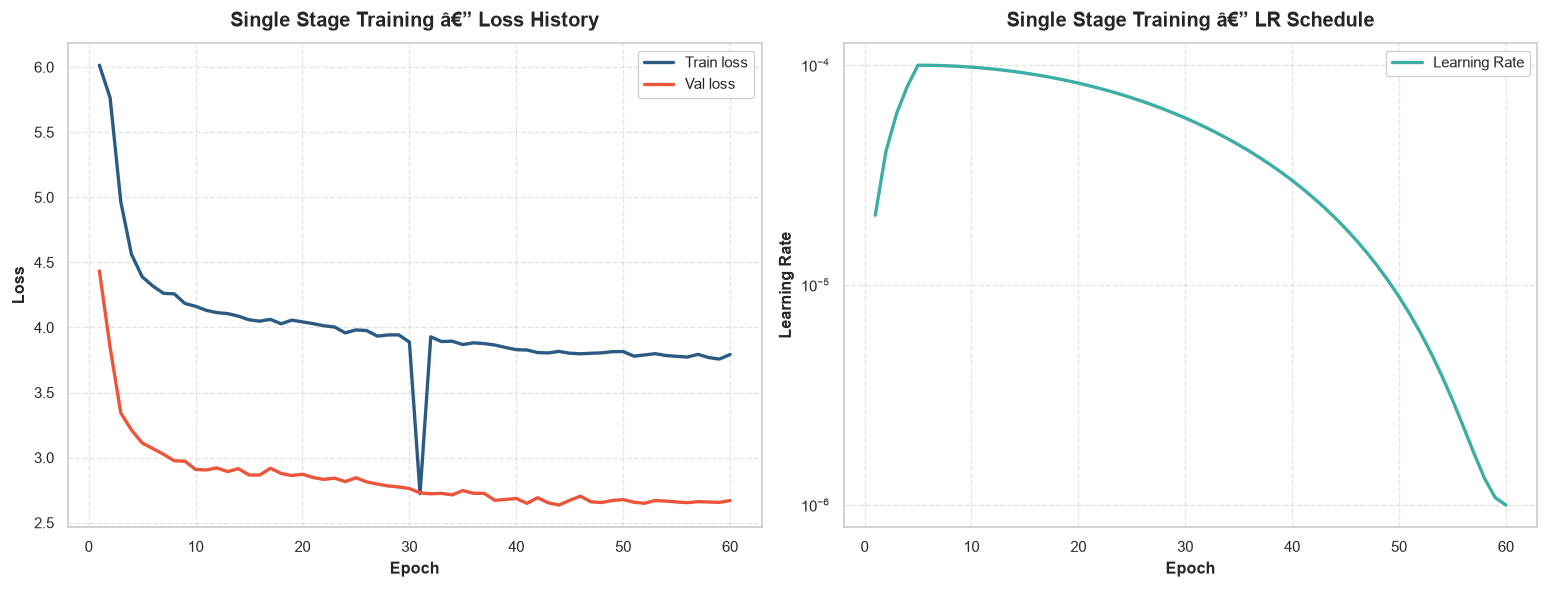

In [ ]:
from main.plots import plot_training_history
import matplotlib.pyplot as plt

fig_training = plot_training_history(
    history=result.history,
    stage="Single Stage Training",
    cfg=notebook_cfg
)
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION — Full metric suite: RMSE, nRMSE, MAE, Pearson r, R^2, VAF
# ─────────────────────────────────────────────────────────────────────────────
import copy, torch
import numpy as np
import pandas as pd
from main import collect_predictions, compute_metrics, load_checkpoint

EMG_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]   # adjust to your dataset labels

# Load LAST checkpoint into a fresh copy of the model
best_model = copy.deepcopy(model)

best_ckpt = f"outputs/checkpoints_method2/{subject_str}/best.pt"
print(f"Loading checkpoint from: {best_ckpt}")
load_checkpoint(best_ckpt, best_model, device)


best_model.eval()
# Collect predictions on the held-out test set (stacks all batches)
P_test, Y_test = collect_predictions(
    best_model, test_loader, prepare_batch, device,
    n_channels=len(EMG_NAMES), use_amp=notebook_cfg["training"]["use_amp"],
)
# Compute all 6 metrics (fully vectorised, float64 internally)
metrics = compute_metrics(P_test, Y_test, channel_names=EMG_NAMES)

# Print the publication-ready ASCII table
print("\n" + metrics.as_table() + "\n")

# Pandas DataFrame for export / further analysis
rows = list(zip(
    metrics.channel_names,
    metrics.rmse, metrics.nrmse, metrics.mae,
    metrics.pearson, metrics.r2, metrics.vaf,
))
df = pd.DataFrame(rows,
    columns=["Channel", "RMSE", "nRMSE%", "MAE", "Pearson r", "R^2", "VAF%"])
df.loc["MEAN"] = ["MEAN"] + [df[c].mean() for c in df.columns[1:]]
#display(df.round(4))

# Publication threshold check (VAF > 80% per Winter 1990)
vaf_pass = int((metrics.vaf >= 80.0).sum())
print(f"\nVAF >= 80% threshold: {vaf_pass}/{len(EMG_NAMES)} channels")

Loading checkpoint from: outputs/checkpoints_method2/P1/best.pt
Loaded checkpoint <- outputs/checkpoints_method2/P1/best.pt  (best_val=2.6584)

Channel                RMSE   nRMSE%      MAE  Pearson r      R^2     VAF%
--------------------------------------------------------------------------
FDI                  1.4120    25.83   1.2349     0.4095  -1.1186    15.96
APB                  1.2980    15.45   1.1453     0.3447  -0.7171     8.15
ADM                  1.1276     7.90   0.8495     0.3227  -0.1590   -13.28
ECR                  0.8994    16.91   0.7827     0.3156  -0.6325     7.31
FCR                  1.2978    11.13   1.0632     0.3275  -0.7989   -21.69
--------------------------------------------------------------------------
 MEAN                1.2070    15.44   1.0151     0.3440  -0.6852    -0.71


VAF >= 80% threshold: 0/5 channels


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# INTERPRETABILITY — Dynamic Continuous Window (True Scale) - PURE EEG
# ─────────────────────────────────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
from main.preprocessing_emg_kin import compute_nnmf_edge_prior
from main.model import PureEEGKGTModel
from scipy.signal import coherence
from main.plots import plot_pure_eeg_triptych
from scipy.signal import butter, sosfiltfilt

# ── TIMELINE SELECTION ────────────────────────────────────────────
start_sec = 0.0   # Start plotting from this second
end_sec   = 10.0  # End plotting at this second
# ──────────────────────────────────────────────────────────────────

fs = CONFIG["data"].get("fs_eeg", 500.0)

# 1. Get the underlying continuous array from the dataset's first series
eeg_full, kin_full, emg_full, block_start_idx = test_ds._windows[0]

# 2. Slice based on the selected seconds
start_idx = block_start_idx + int(start_sec * fs)
end_idx   = block_start_idx + int(end_sec * fs)

raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
raw_emg = torch.tensor(emg_full[start_idx : end_idx])

# 3. Add batch dimension (B=1) and normalize properly via prepare_batch
# We pass None for kinematics since this is the Pure EEG model
model_inputs, emg_norm = prepare_batch(
    raw_eeg.unsqueeze(0), 
    None, 
    raw_emg.unsqueeze(0)
)

eeg_b = model_inputs["eeg"]
emg_b = emg_norm

# 4. Run the model on the custom time window
best_model.eval()

# Inject visualization temperature to SMOOTHEN the heatmap (Must be > 1.0)
for layer in best_model.encoder.layers:
    layer.mhsa.attention_temperature = 4.0

with torch.no_grad():
    pred_b = best_model(eeg_b)

# 5. Convert to numpy and UN-NORMALIZE back to true physical scale
pred_np = pred_b[0].cpu().float().numpy()   
true_np = emg_b[0].cpu().float().numpy()    

emg_mean_np = emg_mean.cpu().numpy()
emg_std_np = emg_std.cpu().numpy()
pred_np = pred_np * emg_std_np + emg_mean_np
true_np = true_np * emg_std_np + emg_mean_np


# 6. Extract EEG temporal attention: (1, H, T, T) -> (H, T, T)
eeg_attn_np = best_model.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
print(f"Raw EEG attention shape: {eeg_attn_np.shape}  (H, T, T)")

from scipy.ndimage import gaussian_filter1d
eeg_attn_np = gaussian_filter1d(eeg_attn_np, sigma=3.0, axis=-1)

# 7. Extract Cross-Attention (EEG Temporal tokens -> Muscle Synergy tokens)
if hasattr(best_model, "cross_attention"):
    cross_attn_np = best_model.cross_attention.last_attn_weights[0].cpu().float().numpy()
    print(f"Cross-attention shape: {cross_attn_np.shape}  (H, N, T)")
else:
    print("Warning: cross_attention not found on best_model.")
    cross_attn_np = np.zeros((4, len(EMG_NAMES), pred_np.shape[0]))

# 8. Generate the 3-panel interpretability money plot
fig = plot_pure_eeg_triptych(
    pred=pred_np,
    target=true_np,
    eeg_attn=eeg_attn_np,
    cross_attn=cross_attn_np,
    muscle_names=EMG_NAMES,
    fs=fs,
    smooth_hz=5.0,
    cfg=CONFIG,
)

plt.show()


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.86 GiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 5.87 GiB is allocated by PyTorch, and 280.85 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# ── DIAGNOSTIC: Pure EEG Residual Decomposition ────────────
from main.plots import plot_pure_eeg_residual_decomposition

fig = plot_pure_eeg_residual_decomposition(
    model      = best_model,
    eeg_window = eeg_b,
    emg_target = true_np,
    emg_mean   = emg_mean,
    emg_std    = emg_std,
    smooth_hz  = 5.0,
    emg_names  = EMG_NAMES,
    fs         = fs,
    cfg        = CONFIG,
)
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STATIC EDGE BIAS + MUSCLE SYNERGY MATRIX
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from main.plots import plot_muscle_synergy_matrix

# ── 1. Biological prior vs. learned static edge bias ──────────────────────
gat = best_model.gat
learned_bias = gat.edge_bias.detach().cpu().numpy()    # (H, N, N)
prior_anchor  = gat.edge_prior_anchor.cpu().numpy()    # (H, N, N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
kw = dict(
    annot=True, fmt=".3f", cmap="mako",
    xticklabels=EMG_NAMES, yticklabels=EMG_NAMES,
    cbar_kws={"shrink": 0.85}, linewidths=0.8, linecolor="white",
)
sns.heatmap(prior_anchor.mean(0), ax=axes[0], **kw)
axes[0].set_title(
    "Biological Prior  (log-prior, mean over heads)\n= NNMF Muscle Synergies + eps", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("From Muscle"); axes[0].set_ylabel("To Muscle")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.heatmap(learned_bias.mean(0), ax=axes[1], **kw)
axes[1].set_title(
    "Learned Static Edge Bias  (after training, mean over heads)\nDeviation from prior = knowledge beyond NNMF prior",
    fontsize=11, fontweight="bold",
)
axes[1].set_xlabel("From Muscle"); axes[1].set_ylabel("To Muscle")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.suptitle(
    "Edge Bias: Biological Prior  vs.  Learned Muscle Synergy",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

# ── 2. GAT attention synergy matrix (full test set) ───────────────────────
all_attn = []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        model_inputs, _ = prepare_batch(raw_eeg, raw_kin, raw_emg)
        
        # Now pass the properly processed inputs to the model
        best_model(model_inputs["eeg"])
        if hasattr(best_model.gat, "last_attn_weights"):
            all_attn.append(best_model.gat.last_attn_weights.cpu().numpy())

if all_attn:
    all_attn_np = np.concatenate(all_attn, axis=0)   # (B*T, H, N, N)
    fig_syn = plot_muscle_synergy_matrix(all_attn_np, EMG_NAMES, cfg=CONFIG)
    plt.show()

# ── 2. GAT attention synergy matrix (full test set) ───────────────────────
all_attn = []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        # IMPORTANT: Pass through prepare_batch to drop rho_GL (13->12) and normalize!
        model_inputs, _ = prepare_batch(raw_eeg, raw_kin, raw_emg)
        
        # Now pass the properly processed inputs to the model
        best_model(
            model_inputs["eeg"],
            model_inputs["kin"],
        )
        if hasattr(best_model.gat, "last_attn_weights"):
            all_attn.append(best_model.gat.last_attn_weights.cpu().numpy())

if all_attn:
    all_attn_np = np.concatenate(all_attn, axis=0)   # (B*T, H, N, N)
    fig_syn = plot_muscle_synergy_matrix(all_attn_np, EMG_NAMES, cfg=CONFIG)
    plt.show()

# ── DIAGNOSTIC: Predicted vs Actual Inter-Muscle Correlation ──────────────
from main.plots import plot_channel_correlation_matrix

# Collect all predictions and targets from the test loader
all_preds_list, all_targets_list = [], []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        model_inputs, emg_norm = prepare_batch(raw_eeg, raw_kin, raw_emg)
        pred = best_model(model_inputs["eeg"])
        all_preds_list.append(pred.cpu().float().numpy())
        all_targets_list.append(emg_norm.cpu().float().numpy())

all_preds_flat   = np.concatenate(all_preds_list,   axis=0).reshape(-1, len(EMG_NAMES))
all_targets_flat = np.concatenate(all_targets_list, axis=0).reshape(-1, len(EMG_NAMES))

fig = plot_channel_correlation_matrix(
    y_pred     = all_preds_flat,
    y_true     = all_targets_flat,
    emg_names  = EMG_NAMES,
    cfg        = CONFIG,
)
plt.show()

# ── DIAGNOSTIC: EMG Error Analysis (Bias / Canopy / Temporal Hotspots) ────
from main.plots import plot_emg_error_analysis

fig = plot_emg_error_analysis(
    y_pred    = all_preds_flat,
    y_true    = all_targets_flat,
    emg_names = EMG_NAMES,
    fs        = fs,
    cfg       = CONFIG,
)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from main.plots import (
    plot_pure_eeg_latency_lag,
    plot_pure_eeg_spectral_power_decomposition,
)

best_model.eval()

# ── PLOT 1: Neural-Mechanical Latency Lag (Time-Shifted Cross-Correlation) ──
print("Generating Plot 1: Neural-Mechanical Latency Lag Analysis...")
fig_lat = plot_pure_eeg_latency_lag(
    model=best_model,
    eeg_window=eeg_b,
    emg_target=true_np,
    emg_names=EMG_NAMES,
    fs=500,
    max_lag_ms=250,
    emg_mean=emg_mean,
    emg_std=emg_std,
    cfg=CONFIG
)
plt.show()

# ── PLOT 2: Spectral Power Decomposition (PSD Bandwidth & Canopy Check) ──
print("\nGenerating Plot 2: Spectral Power Decomposition (Welch's PSD)...")
fig_spec = plot_pure_eeg_spectral_power_decomposition(
    model=best_model,
    eeg_window=eeg_b,
    emg_target=true_np,
    emg_names=EMG_NAMES,
    fs=500,
    max_freq_hz=20.0,
    emg_mean=emg_mean,
    emg_std=emg_std,
    cfg=CONFIG
)
plt.show()